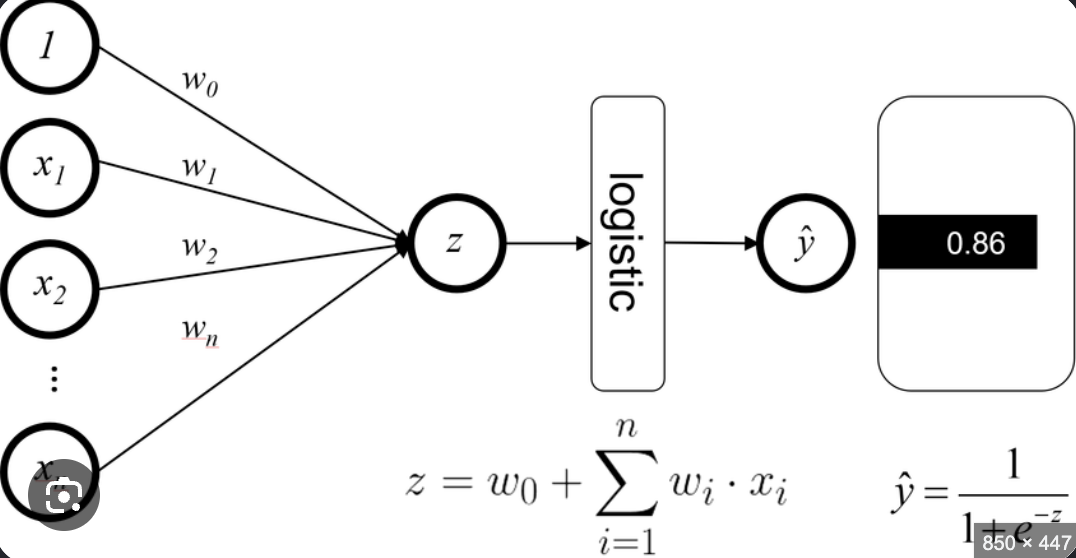

<span style="color: #aaf71cff">IMPORTS</span>

In [143]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader , random_split
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torchvision.datasets import ImageFolder
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from ptflops import get_model_complexity_info 
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms.functional as F

Images download and Random Genenrator

In [144]:
gen = torch.Generator().manual_seed(42)

## transformation of (image folder -> dataset)

taking the mean, std _dev calculated in the dataset analsysis

In [ ]:
mean=[0.4887, 0.4554, 0.4172]
std =[0.2601, 0.2533, 0.2560]

In [145]:
custom_transform = transforms.Compose([

    transforms.Resize((64,64)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.4887, 0.4554, 0.4172],

        std =[0.2601, 0.2533, 0.2560]

    )

])

In [146]:
dataset= ImageFolder(root="data", transform=custom_transform)

## dataset splitting

In [147]:
train_size= int(0.8* len(dataset))
test_size= len(dataset) - train_size

train_dataset, test_dataset= random_split(dataset, [train_size, test_size], generator=gen)

## dataset loading into dataloader from the local files

In [148]:
train_loader=DataLoader(train_dataset , batch_size=64, shuffle=True, pin_memory=True)
test_loader=DataLoader(test_dataset, batch_size=64, shuffle=False ,pin_memory=True)

## model class creation in torch

In [149]:
device = torch.device('mps')

In [150]:
class LogReg(nn.Module):
    def __init__(self):
        super().__init__() ## inheritence from nn.Module
        self.model= nn.Sequential(
            nn.Flatten(),           # 3 x 2D to 1 D
            nn.Linear(64*64*3,1),   # Linear layer
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.model(x)

In [151]:
model = LogReg().to(device)

In [152]:
model

LogReg(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=1, bias=True)
    (2): Sigmoid()
  )
)

## Loss and optim

In [153]:
epochs=10

In [154]:
loss= nn.BCELoss()
optim= AdamW(model.parameters(), lr= 1e-3)
scheduler = CosineAnnealingLR(optim,T_max=epochs)

In [155]:
loss

BCELoss()

In [156]:
# label is a tensor : [0,1,0]       (3,)
# output is in the format: [[0.5],[0,6],[0.7]]      (3,1)

 ## Training loop
 

In [157]:
mean= torch.tensor(mean)
std_dev= torch.tensor(std_dev)

/var/folders/j2/9hsk1jq12rjbt8qz1vrdnbth0000gn/T/ipykernel_16006/2649908780.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean= torch.tensor(mean)
/var/folders/j2/9hsk1jq12rjbt8qz1vrdnbth0000gn/T/ipykernel_16006/2649908780.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std_dev= torch.tensor(std_dev)


In [158]:
print(custom_transform)

dummy = Image.open("/Users/par_04/code_playground/ml/Animal_classsfier/dog.jpeg").convert("RGB")

x = custom_transform(dummy)

print(x.shape)

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.4887, 0.4554, 0.4172], std=[0.2601, 0.2533, 0.256])
)
torch.Size([3, 64, 64])


In [159]:
mean = mean.view(1,3,1,1).to(device)
std_dev = std_dev.view(1,3,1,1).to(device)
start = time.time()
for epoch in tqdm(range(epochs)):
    model.train()

    total=0
    correct=0
    epoch_loss=0.0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        
        labels= labels.float().unsqueeze(1).to(device)
        # converts label to float and adds a dim to make the vector a matrix
        #   (batchsize ,)       ->>>.   (batch_size,1)

        outs= model(imgs)# raw probs

        l = loss(outs,labels)
        
        optim.zero_grad()# clears the computation graph for each epoch
        l.backward()     # compute the grads
        optim.step()        # grad descent

        preds=(outs>0.5).float()        # prob to pred
        #   set of  True or False converted to 1.0 or 0.0 based on True/False

        correct+=(preds==labels).sum().item()
        #   count the points where preds and labels match and take sum and remove tensor

        total += labels.size(0)


        epoch_loss+=l.item() 
        #In PyTorch, loss.item() extracts the loss value from 
        # a single-element tensor and converts it into a standard Python float
    scheduler.step()
    print(f"loss at epoch (per batch): {epoch+1} is {(epoch_loss)/len(train_loader):.4f}")
    print(f"accuracy at epoch : {epoch+1} is {correct/total}")

train_time = time.time() -start

  0%|          | 0/10 [00:00<?, ?it/s]/Users/par_04/code_playground/ml/Animal_classsfier/.animal/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 10%|█         | 1/10 [00:30<04:38, 30.96s/it]

loss at epoch (per batch): 1 is 0.8033
accuracy at epoch : 1 is 0.5654065406540654


 20%|██        | 2/10 [01:03<04:12, 31.62s/it]

loss at epoch (per batch): 2 is 0.7953
accuracy at epoch : 2 is 0.5877087708770877


 30%|███       | 3/10 [01:33<03:36, 30.91s/it]

...

loss at epoch (per batch): 8 is 0.6165
accuracy at epoch : 8 is 0.6628662866286629


 90%|█████████ | 9/10 [04:42<00:31, 31.82s/it]

loss at epoch (per batch): 9 is 0.5957
accuracy at epoch : 9 is 0.6791179117911791


100%|██████████| 10/10 [05:14<00:00, 31.46s/it]

loss at epoch (per batch): 10 is 0.5843
accuracy at epoch : 10 is 0.693969396939694


In [160]:
train_time
# in secs

314.59624123573303

## Testing loop

In [161]:
start = time.time()
model.eval()
with torch.no_grad():
        all_labels=[]
        all_preds=[]
        LOSS=0.0
        for imgs, labels in test_loader:

                imgs = imgs.to(device)
                
                labels= labels.float().unsqueeze(1).to(device)
                # converts label to float and adds a dim to make the vector a matrix
                #   (batchsize ,)       ->>>.   (batch_size,1)

                outs= model(imgs)# raw probs
                l= loss(outs, labels)
                preds=(outs>0.5).float()        # prob to pred
                #   set of  True or False converted to 1.0 or 0.0 based on True/False

                correct+=(preds==labels).sum().item()
                #   count the points where preds and labels match and take sum and remove tensor
                
                total += labels.size(0)
                
                LOSS+=l.item()
                all_labels.extend(labels.cpu().numpy().flatten())
                all_preds.extend(preds.cpu().numpy().flatten())
                #In PyTorch, loss.item() extracts the loss value from 
                # a single-element tensor and converts it into a standard Python float
        test_time = time.time() - start        
        print(f"LOSS per batch:  {(LOSS)/len(test_loader):.4f}")
        print(f"accuracy  :   {100*correct/total :.4f}%")
        print(f"Time  :   {test_time :.4f}s")

LOSS per batch:  0.6725
accuracy  :   67.8174%
Time  :   7.9638s


## test image visualization

This line of code rearranges a PyTorch image tensor's dimensions from the standard deep learning format (Channels, Height, Width) to the plotting format (Height, Width, Channels) so it can be rendered properly using matplotlib.pyplot.imshow.
<br><br>
converts (C,H,W) ----> (H,W,C)

In [162]:
IMAGES, LABLES= next(iter(train_loader))
image= IMAGES[4]
label=LABLES[4].item()

In [163]:
output=model(image.unsqueeze(0).to(device))

In [164]:
cls=["cat","dog"]

In [165]:
output.shape

torch.Size([1, 1])

In [166]:
output

tensor([[0.9348]], device='mps:0', grad_fn=<SigmoidBackward0>)

In [167]:
prediction= int(output>0.5)
conf= output.cpu().detach().float().item()

/var/folders/j2/9hsk1jq12rjbt8qz1vrdnbth0000gn/T/ipykernel_16006/3295563569.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std_dev=torch.tensor(std_dev)
/var/folders/j2/9hsk1jq12rjbt8qz1vrdnbth0000gn/T/ipykernel_16006/3295563569.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean=torch.tensor(mean)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.622581..2.2765625].


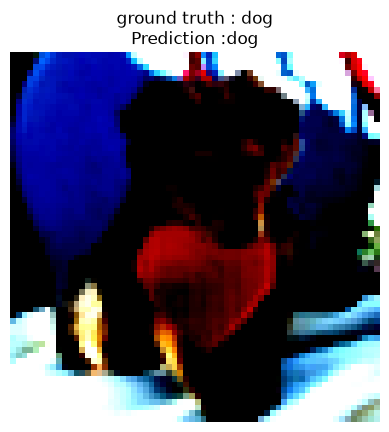

In [168]:
plt.title(f"ground truth : {cls[label]}\n" f"Prediction :{cls[prediction]}")
img = image.to(device)
std_dev=torch.tensor(std_dev)
mean=torch.tensor(mean)
img = img * std_dev + mean
plt.imshow(image.permute(1,2,0))
plt.axis("off")
plt.show()

In [169]:
num_paramerters=0
for p in model.parameters():
    print(p)
    num_paramerters+=p.numel()
    #weights
    #bias

Parameter containing:
tensor([[ 0.0245, -0.0033, -0.0258,  ...,  0.0076,  0.0215,  0.0128]],
       device='mps:0', requires_grad=True)
Parameter containing:
tensor([-0.0674], device='mps:0', requires_grad=True)


In [170]:
num_paramerters

12289

In [171]:
memory_usage= torch.mps.current_allocated_memory()/1024**2

In [172]:
memory_usage

1.50537109375

In the ptflops library, MACs (Multiply-Accumulate Operations) and Params (Parameters) are the two primary metrics used to measure the computational complexity and size of a PyTorch deep learning model

In [173]:
macs, params = get_model_complexity_info(model,(3,64,64),as_strings=False,print_per_layer_stat=False)

In [174]:
macs

12289

In [175]:
params

12289

MAC operation :Multiply first, then add.
<br>flops = 2*macs

In [176]:
flops=2* macs

In [177]:
flops

24578

## custom inference

#### file path -> pil image -> tensor -> unsqueeze(0) -> pass to model

In [178]:
model.eval()

LogReg(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=1, bias=True)
    (2): Sigmoid()
  )
)

In [179]:
from PIL import Image

In [183]:
model.eval()
dog = Image.open("/Users/par_04/code_playground/ml/Animal_classsfier/dog.jpeg").convert("RGB")
cat=Image.open("/Users/par_04/code_playground/ml/Animal_classsfier/cat.png").convert("RGB")

In [184]:
dog_tensor=custom_transform(dog)
cat_tensor=custom_transform(cat)

In [185]:
type(dog_tensor)

torch.Tensor

In [186]:
start= time.time()
infer_out1 = model(dog_tensor.unsqueeze(0).to(device))
infer_time1 = time.time()- start

In [187]:
predicton1= int(infer_out1 > 0.5)
confidence1 = infer_out1.cpu().detach().float().item()

In [188]:
predicton1

1

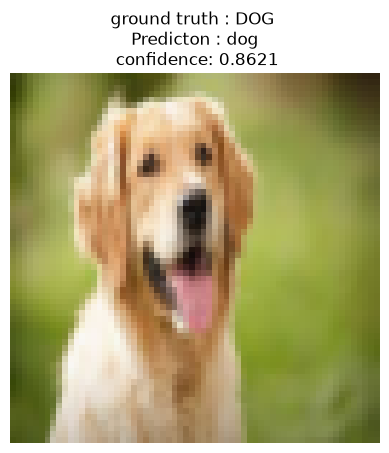

In [189]:
plt.title(f"ground truth : DOG \n Predicton : {cls[predicton1]} \n confidence: {confidence1:.4f}")
img= dog_tensor.squeeze(0).cpu()
img = img * std_dev.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

In [190]:
start= time.time()
infer_out2 = model(cat_tensor.unsqueeze(0).to(device))
infer_time2 = time.time()- start

In [191]:
infer_out2

tensor([[0.5949]], device='mps:0', grad_fn=<SigmoidBackward0>)

In [195]:
predicton2= int(infer_out2 > 0.5)
confidence2 = infer_out2.cpu().detach().float().item()

In [196]:
predicton2

1

In [197]:
confidence2=1-confidence2

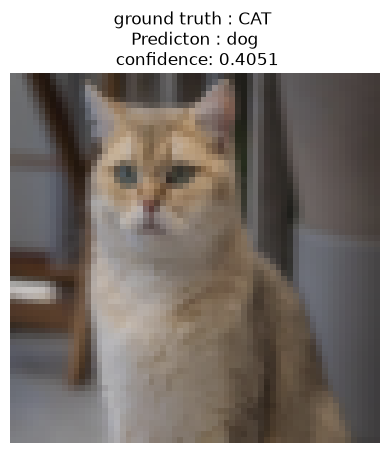

In [198]:
plt.title(f"ground truth : CAT \n Predicton : {cls[predicton2]} \n confidence: {confidence2:.4f}")
img= cat_tensor.squeeze(0).cpu()
img = img * std_dev.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

# METRICS

In [199]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc= accuracy_score(all_labels, all_preds)
pre = precision_score(all_labels, all_preds),
rec= recall_score(all_labels, all_preds)
f1= f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

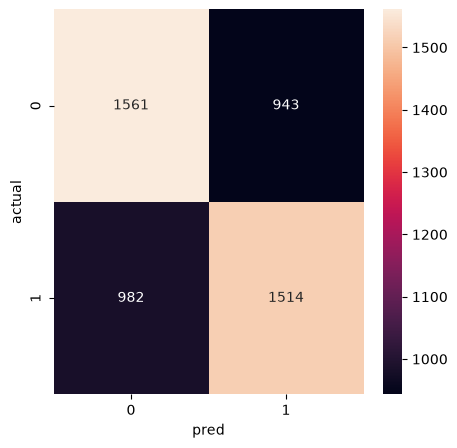

In [200]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt= 'd')
plt.xlabel("pred")
plt.ylabel("actual")
plt.show()

In [202]:
print("="*60)
print("LOGISTIC REGRESSION EVALUATION RESULTS")
print("="*60)

print(f"Model         : Logistic Regression")
print(f"Epochs        : {epochs}")

print()

print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {pre[0]:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1 Score      : {f1:.4f}")

print()

print(f"Training Time : {train_time:.2f}s")
print(f"Testing Time  : {test_time:.2f}s")

print()

print(f"Parameters    : {num_paramerters:,}")
print(f"Memory Usage  : {memory_usage:.2f} MB")

print()

print("Classes       :", cls)

print()

print("Confusion Matrix")
print(cm)

print("="*60)

LOGISTIC REGRESSION EVALUATION RESULTS
Model         : Logistic Regression
Epochs        : 10

Accuracy      : 0.6150
Precision     : 0.6162
Recall        : 0.6066
F1 Score      : 0.6113

Training Time : 314.60s
Testing Time  : 7.96s

Parameters    : 12,289
Memory Usage  : 1.51 MB

Classes       : ['cat', 'dog']

Confusion Matrix
[[1561  943]
 [ 982 1514]]


In [203]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=cls
    )
)

              precision    recall  f1-score   support

         cat       0.61      0.62      0.62      2504
         dog       0.62      0.61      0.61      2496

    accuracy                           0.61      5000
   macro avg       0.62      0.61      0.61      5000
weighted avg       0.62      0.61      0.61      5000



precision :  When I say “DOG”, how often am I correct?

recall: Out of all actual dogs, how many did I find?

F1 score: score balancing Precision and Recall.<br>
f1 = 2pr/(p+r)
